# Read Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_style()
warnings.filterwarnings("ignore")

In [2]:
df_train = pd.read_csv("/kaggle/input/notebooks/davidvista/data-preparation-modeling/train_aug.csv")
df_test = pd.read_csv("/kaggle/input/notebooks/davidvista/data-preparation-modeling/test_aug.csv")
df_emerging = pd.read_csv("/kaggle/input/notebooks/davidvista/data-preparation-modeling/emerging_aug.csv")

In [3]:
df_train.head(5)

,author_playtime_last_two_weeks,author_num_reviews,author_num_games_owned,author_playtime_forever,weighted_vote_score,total_games,avg_initial_price,avg_discount_percent,avg_achievement_count,avg_languages,years_past_first_release,release_frequency,percent_free,genre_count,category_count,is_top,cluster_premium_discounters,cluster_hardcore_niche,cluster_high_volume_diversified,cluster_free_to_play
0,0.000000,24.333333,416.000000,8.000000,0.551310,1,0.000000,0.000000,20.000000,1.000000,7,0.125000,1.0,1,1,0,0,0,0,1
1,0.000000,247.000000,1011.500000,26.500000,0.564949,6,5.990000,0.000000,20.000000,1.000000,4,1.200000,0.0,2,3,0,0,0,0,0
2,58.230769,38.692308,68.000000,280.923077,0.503663,44,17.080910,0.695455,18.181818,9.454545,5,7.333333,0.0,3,12,0,1,0,0,0
3,0.000000,738.607843,1340.666667,447.941176,0.534286,116,1.783103,0.077586,21.482759,1.000000,6,16.571429,0.0,7,9,0,0,0,1,0
4,0.000000,67.000000,602.000000,5.000000,0.525547,9,3.990000,0.000000,20.000000,1.000000,7,1.125000,0.0,3,3,0,0,0,0,0


# Modeling Technique Selection

The following models are selected to fullfill the data mining and business objectives:

1. **Logistic Regression**: the simplest and highly interpretable model for classification, requires scaling the input data.
2. **Decision Tree**: the non-linear modeling tool with high explainability.
3. **Random Forest**: the ensemble approach to leverage the performance of each decision tree.
4. **Gradient Boosting**: the most powerful approach in the modeling of tabular data.

# Test Design

Recall the data mining goals and their success criteria, the following table summarizes the validation design of this notebook:

| Goal | Test(s) |
|------|---------|
| **ROC‑AUC > 0.8** and **≥3 features with importance ≥1% of max** | • Compute ROC‑AUC on test set<br>• Generate interpretability report (SHAP / built‑in importance) and count features meeting the 1% threshold |
| **Calibration: Brier < 0.1, ECE < 0.1** | • Compute Brier score and expected calibration error (ECE) on test set |
| **Precision > 0.6** (at validation‑tuned threshold) with **recall in [0.20, 0.30]** | • At the threshold selected on validation data, compute precision and recall on the test set |

# Build Model

The following steps are performed for each model:
1. Data preparation
2. K-Fold hyperparameter tuning by ROC-AUC score
   - Cross-validation;
   - Selection of the best model;
   - Building the best model.
3. Selection of the best threshold (using out-of-fold set predictions)

## Helper Functions

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from itertools import product
from tqdm import tqdm

def oof_hyperparameter_tuning(model_class, param_grid, X, y, cv=5, scoring=roc_auc_score, random_state=0):
    """
    Perform hyperparameter tuning using k‑fold CV, collect out‑of‑fold predictions
    for the best parameter set, and return a final model trained on the full dataset.

    Parameters
    ----------
    model_class : class
        An sklearn‑like class with `fit` and `predict_proba` methods.
        Example: LogisticRegression, XGBClassifier.
    param_grid : dict
        Hyperparameter grid, e.g. {'C': [0.1, 1.0], 'penalty': ['l2']}
    X : pd.DataFrame or np.ndarray
        Feature matrix.
    y : pd.Series or np.ndarray
        Target vector (binary). The name `is_top` is not required.
    cv : int, default=5
        Number of folds for StratifiedKFold.
    scoring : callable, default=roc_auc_score
        Metric to maximise. Must accept (y_true, y_pred_proba).
    random_state : int, default=0
        For reproducibility.

    Returns
    -------
    best_model : object
        Model fitted on the full training set with the best hyperparameters.
    best_oof_proba : np.ndarray
        Out‑of‑fold predicted probabilities for the training set (length = len(X)).
    best_params : dict
        The hyperparameters that gave the highest CV score.
    best_score : float
        The average CV score of the best model.
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    
    # Generate all parameter combinations
    keys = param_grid.keys()
    values = param_grid.values()
    param_combinations = [dict(zip(keys, v)) for v in product(*values)]
    
    best_score = -np.inf
    best_params = None
    best_oof_proba = None
    
    # For each parameter combination
    for params in tqdm(param_combinations):
        oof_proba = np.zeros(len(X))
        fold_scores = []
        
        for train_idx, val_idx in skf.split(X, y):
            X_train_fold = X.iloc[train_idx] if hasattr(X, 'iloc') else X[train_idx]
            y_train_fold = y.iloc[train_idx] if hasattr(y, 'iloc') else y[train_idx]
            X_val_fold = X.iloc[val_idx] if hasattr(X, 'iloc') else X[val_idx]
            y_val_fold = y.iloc[val_idx] if hasattr(y, 'iloc') else y[val_idx]
            
            model = model_class(**params)
            model.fit(X_train_fold, y_train_fold)
            pred_proba = model.predict_proba(X_val_fold)[:, 1]
            oof_proba[val_idx] = pred_proba
            fold_scores.append(scoring(y_val_fold, pred_proba))
        
        mean_score = np.mean(fold_scores)
        if mean_score > best_score:
            best_score = mean_score
            best_params = params
            best_oof_proba = oof_proba.copy()
    
    return best_oof_proba, best_params, best_score

In [5]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV

def oof_threshold_tuning(base_model_class, base_params, X, y, cv=5, calibration_method='isotonic', scoring=precision_score, target_recall=0.25):
    """
    Generate out‑of‑fold calibrated probabilities and select threshold that maximises a scoring metric.
    
    Returns:
        best_threshold : float
        oof_proba : np.ndarray (calibrated probabilities for each sample)
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=0)
    oof_proba = np.zeros(len(X))
    
    for train_idx, val_idx in skf.split(X, y):
        X_train_fold = X.iloc[train_idx] if hasattr(X, 'iloc') else X[train_idx]
        y_train_fold = y.iloc[train_idx] if hasattr(y, 'iloc') else y[train_idx]
        X_val_fold = X.iloc[val_idx] if hasattr(X, 'iloc') else X[val_idx]
        
        # Train base model
        base_model = base_model_class(**base_params)
        base_model.fit(X_train_fold, y_train_fold)
        
        # Calibrate on the same training fold (using cross‑validation inside)
        calibrated = CalibratedClassifierCV(base_model, method=calibration_method, cv=5)
        calibrated.fit(X_train_fold, y_train_fold)
        
        # Predict on validation fold
        oof_proba[val_idx] = calibrated.predict_proba(X_val_fold)[:, 1]

    thresholds = np.linspace(0, 1, 100)
    best_threshold = 0.5
    best_precision = 0.0
    
    for thr in thresholds:
        preds = (oof_proba >= thr).astype(int)
        if preds.sum() == 0:
            continue
        recall = recall_score(y, preds, zero_division=0)
        if recall >= target_recall:
            precision = precision_score(y, preds, zero_division=0)
            if precision > best_precision:
                best_precision = precision
                best_threshold = thr
    
    return best_threshold, best_precision

In [6]:
from sklearn.metrics import precision_score, recall_score

def select_threshold(y_val_proba, y_true, target_recall=0.25):
    """
    Select threshold that achieves at least target_recall, maximizing precision.
    
    Parameters
    ----------
    y_val_proba : array-like
        Predicted probabilities for validation set.
    y_true : array-like
        True labels.
    target_recall : float, default=0.1
        Minimum recall to achieve.
    
    Returns
    -------
    best_threshold : float
        Threshold that gives highest precision while recall >= target_recall.
    best_precision : float
        Precision at that threshold.
    """
    thresholds = np.linspace(0, 1, 100)
    best_threshold = 0.5
    best_precision = 0.0
    
    for thr in thresholds:
        preds = (y_val_proba >= thr).astype(int)
        if preds.sum() == 0:
            continue
        recall = recall_score(y_true, preds, zero_division=0)
        if recall >= target_recall:
            precision = precision_score(y_true, preds, zero_division=0)
            if precision > best_precision:
                best_precision = precision
                best_threshold = thr
                
    return best_threshold, best_precision

In [7]:
import shap
import matplotlib.pyplot as plt

def shap_importance(model, X, feature_names=None, plot=True):
    """SHAP feature importance for any model with predict_proba."""
    def f(x):
        return model.predict_proba(x)[:, 1]
    explainer = shap.Explainer(f, X)
    shap_values = explainer(X)
    if plot:
        shap.summary_plot(shap_values, X, feature_names=feature_names, show=False)
        plt.show()
    return shap_values

In [8]:
def shap_bar_plot(shap_values, feature_names=None, max_display=20, figsize=(10, 6)):
    """
    Bar plot of mean absolute SHAP values per feature.
    
    Parameters
    ----------
    shap_values : shap.Explanation or array-like
        SHAP values (output from shap.Explainer).
    feature_names : list, optional
        List of feature names.
    max_display : int
        Maximum number of features to display.
    figsize : tuple
        Figure size.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    if hasattr(shap_values, 'values'):
        shap_vals = shap_values.values
    else:
        shap_vals = shap_values
    
    # Compute mean absolute SHAP per feature
    mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)
    
    # Sort descending
    idx = np.argsort(mean_abs_shap)[::-1][:max_display]
    features = [feature_names[i] if feature_names else f"Feature {i}" for i in idx]
    values = mean_abs_shap[idx]
    
    plt.figure(figsize=figsize)
    plt.barh(features[::-1], values[::-1])
    plt.xlabel("Mean |SHAP value|")
    plt.title("Feature Importance (SHAP)")
    plt.tight_layout()
    plt.show()

## Logistic Regression

### 1. Data Preparation



In [9]:
from sklearn.preprocessing import RobustScaler

y_train = df_train['is_top'].to_numpy().copy()
X_train = df_train.drop(columns=['is_top']).to_numpy().copy()

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)

### 2. Hyperparameter tuning

In [10]:
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.1, 1.0, 10.0],
    'penalty': ['l1', 'l2'], 
    'solver': ['liblinear'],
    'max_iter': [1000]
}

In [11]:
lr_oof_proba, lr_best_params, lr_best_score = oof_hyperparameter_tuning(
    model_class=LogisticRegression,
    param_grid=param_grid,
    X=X_train_scaled,
    y=y_train,
    cv=5
)

print("Best parameters:", lr_best_params)
print("Best CV ROC-AUC:", lr_best_score)

100%|██████████| 6/6 [00:06<00:00,  1.01s/it]

Best parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 1000}
Best CV ROC-AUC: 0.7805481489011152


In [12]:
lr_best_model = LogisticRegression(**lr_best_params)
lr_best_model.fit(X_train_scaled, y_train)

LogisticRegression(C=0.1, max_iter=1000, penalty='l1', solver='liblinear')

### 3. Selection of the best threshold

In [13]:
lr_threshold, lr_best_precision = select_threshold(lr_oof_proba, y_train)

print(f"Optimal threshold: {round(lr_threshold, 4)}")
print(f"Best precision: {round(lr_best_precision, 4)}")

Optimal threshold: 0.2525
Best precision: 0.3831


## Decision Tree

### 1. Data Preparation

In [14]:
from sklearn.preprocessing import RobustScaler

y_train = df_train['is_top'].to_numpy().copy()
X_train = df_train.drop(columns=['is_top']).to_numpy().copy()

### 2. Hyperparameter tuning

In [15]:
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2'],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced']
}

In [16]:
from sklearn.tree import DecisionTreeClassifier

dt_oof_proba, dt_best_params, dt_best_score = oof_hyperparameter_tuning(
    model_class=DecisionTreeClassifier,
    param_grid=param_grid,
    X=X_train,
    y=y_train,
    cv=5
)

print("Best parameters:", dt_best_params)
print("Best CV ROC-AUC:", dt_best_score)

100%|██████████| 270/270 [02:07<00:00,  2.12it/s]

Best parameters: {'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'criterion': 'entropy', 'class_weight': 'balanced'}
Best CV ROC-AUC: 0.8159842345261671


In [17]:
dt_best_model = DecisionTreeClassifier(**dt_best_params)
dt_best_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=5)

### 3. Selection of the best threshold

In [18]:
dt_threshold, dt_best_precision = select_threshold(dt_oof_proba, y_train)

print(f"Optimal threshold: {round(dt_threshold, 4)}")
print(f"Best precision: {round(dt_best_precision, 4)}")

Optimal threshold: 0.8586
Best precision: 0.3918


## Random Forest

### 1. Data Preparation

In [19]:
from sklearn.preprocessing import RobustScaler

y_train = df_train['is_top'].to_numpy().copy()
X_train = df_train.drop(columns=['is_top']).to_numpy().copy()

### 2. Hyperparameter tuning

In [20]:
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [10, None],
    'min_samples_split': [2],
    'min_samples_leaf': [4],
    'max_features': ['sqrt'],
    'bootstrap': [True],
    'class_weight': ['balanced'],
    'n_jobs': [-1]
}

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_oof_proba, rf_best_params, rf_best_score = oof_hyperparameter_tuning(
    model_class=RandomForestClassifier,
    param_grid=param_grid,
    X=X_train,
    y=y_train,
    cv=5
)

print("Best parameters:", rf_best_params)
print("Best CV ROC-AUC:", rf_best_score)

100%|██████████| 4/4 [00:56<00:00, 14.17s/it]

Best parameters: {'n_estimators': 300, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': 'balanced', 'n_jobs': -1}
Best CV ROC-AUC: 0.8697870435764529


In [22]:
rf_best_model = RandomForestClassifier(**rf_best_params)
rf_best_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=4,
                       n_estimators=300, n_jobs=-1)

### 3. Selection of the best threshold

In [23]:
rf_threshold, rf_best_precision = select_threshold(rf_oof_proba, y_train)

print(f"Optimal threshold: {round(rf_threshold, 4)}")
print(f"Best precision: {round(rf_best_precision, 4)}")

Optimal threshold: 0.6263
Best precision: 0.5834


## Gradient Boosting

### 1. Data Preparation

In [24]:
y_train = df_train['is_top'].to_numpy().copy()
X_train = df_train.drop(columns=['is_top']).to_numpy().copy()

### 2. Hyperparameter tuning

In [25]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, (len(y_train) - sum(y_train)) / sum(y_train)]  # auto balance
}

In [26]:
from xgboost import XGBClassifier

gb_oof_proba, gb_best_params, gb_best_score = oof_hyperparameter_tuning(
    model_class=XGBClassifier,
    param_grid=param_grid,
    X=X_train,
    y=y_train,
    cv=5
)

print("Best parameters:", gb_best_params)
print("Best CV ROC-AUC:", gb_best_score)

100%|██████████| 216/216 [08:35<00:00,  2.39s/it]

Best parameters: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1}
Best CV ROC-AUC: 0.8702808550297896


In [27]:
gb_best_model = XGBClassifier(**gb_best_params)
gb_best_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

### 3. Selection of the best threshold

In [28]:
gb_threshold, gb_best_precision = select_threshold(gb_oof_proba, y_train)

print(f"Optimal threshold: {round(gb_threshold, 4)}")
print(f"Best precision: {round(gb_best_precision, 4)}")

Optimal threshold: 0.4141
Best precision: 0.5939


## Calibrated Models

In [29]:
dt_base_model = DecisionTreeClassifier(**dt_best_params)
rf_base_model = RandomForestClassifier(**rf_best_params)

In [30]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay


dt_calibrated = CalibratedClassifierCV(dt_base_model, method='isotonic', cv=5)
rf_calibrated = CalibratedClassifierCV(rf_base_model, method='isotonic', cv=5)

In [31]:
dt_calibrated.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=DecisionTreeClassifier(class_weight='balanced',
                                                        criterion='entropy',
                                                        max_depth=5),
                       method='isotonic')

In [32]:
rf_calibrated.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=RandomForestClassifier(class_weight='balanced',
                                                        min_samples_leaf=4,
                                                        n_estimators=300,
                                                        n_jobs=-1),
                       method='isotonic')

In [33]:
dt_calibrated_threshold, dt_calibrated_precision =oof_threshold_tuning(
    base_model_class=DecisionTreeClassifier,
    base_params=dt_best_params,
    X=X_train_scaled,
    y=y_train,
    cv=5
)

print(f"Optimal threshold: {round(dt_calibrated_threshold, 4)}")
print(f"Best precision: {round(dt_calibrated_precision, 4)}")

Optimal threshold: 0.3636
Best precision: 0.4535


In [34]:
rf_calibrated_threshold, rf_calibrated_precision =oof_threshold_tuning(
    base_model_class=RandomForestClassifier,
    base_params=rf_best_params,
    X=X_train_scaled,
    y=y_train,
    cv=5
)

print(f"Optimal threshold: {round(rf_calibrated_threshold, 4)}")
print(f"Best precision: {round(rf_calibrated_precision, 4)}")

Optimal threshold: 0.4444
Best precision: 0.5759


# Assess Models

## Test Data Preparation

In [35]:
y_test = df_test['is_top'].copy()
X_test = df_test.drop(columns=['is_top']).copy()
X_test_scaled = scaler.transform(X_test)

data_dict = {
    'Logistic Regression': X_test_scaled,
    'Decision Tree': X_test,
    'Random Forest': X_test,
    'XGBoost': X_test,
    'Decision Tree (calibrated)': X_test,
    'Random Forest (calibrated)': X_test,
}

## Interpretability Report

### LogisticRegression

In [36]:
y_test = df_test['is_top'].copy()
X_test = df_test.drop(columns=['is_top']).copy()
X_test_scaled = scaler.transform(X_test)

feature_names = list(df_test.drop(columns=['is_top']).columns)

**Coefficients Report**

In [37]:
import pandas as pd

coefs = lr_best_model.coef_[0]
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)
print(coef_df)

                            Feature  Coefficient
7              avg_discount_percent     2.164641
17  cluster_high_volume_diversified     0.535661
10         years_past_first_release     0.481549
18             cluster_free_to_play    -0.455030
15      cluster_premium_discounters     0.337284
6                 avg_initial_price     0.320254
12                     percent_free    -0.273084
13                      genre_count    -0.176072
16           cluster_hardcore_niche    -0.100999
14                   category_count     0.096200
4               weighted_vote_score    -0.059193
11                release_frequency     0.045169
2            author_num_games_owned     0.014093
1                author_num_reviews     0.010874
3           author_playtime_forever    -0.008284
5                       total_games    -0.007218
9                     avg_languages    -0.001034
8             avg_achievement_count     0.000109
0    author_playtime_last_two_weeks     0.000026


**SHAP Values**

PermutationExplainer explainer: 5391it [01:06, 73.19it/s]                          


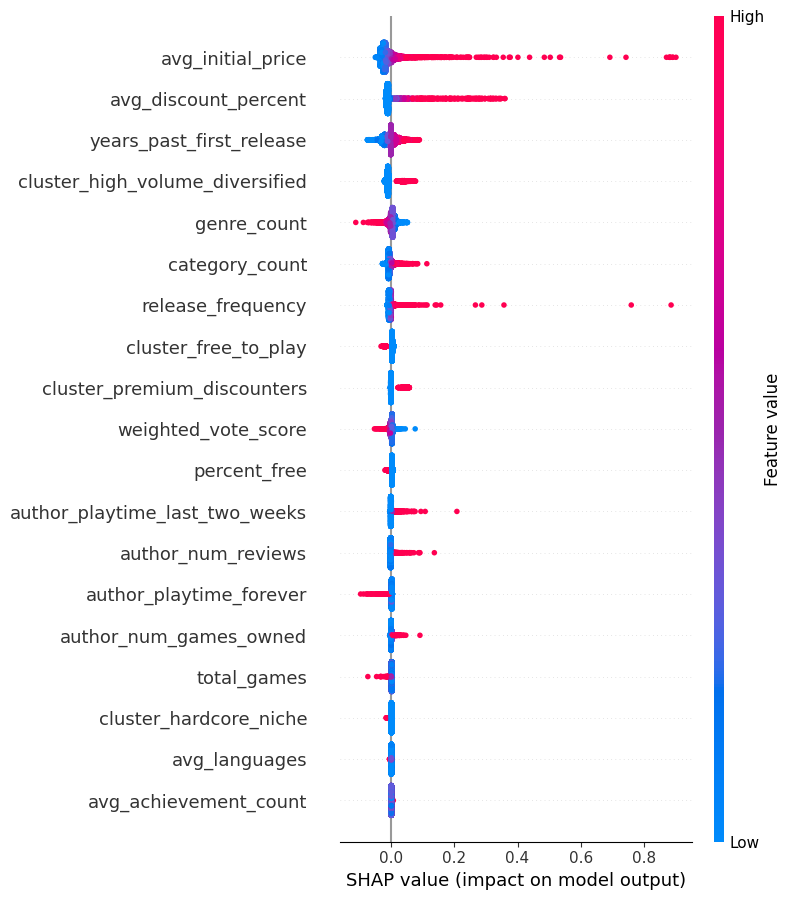

In [38]:
lr_shap_values = shap_importance(lr_best_model, X_test_scaled, feature_names)

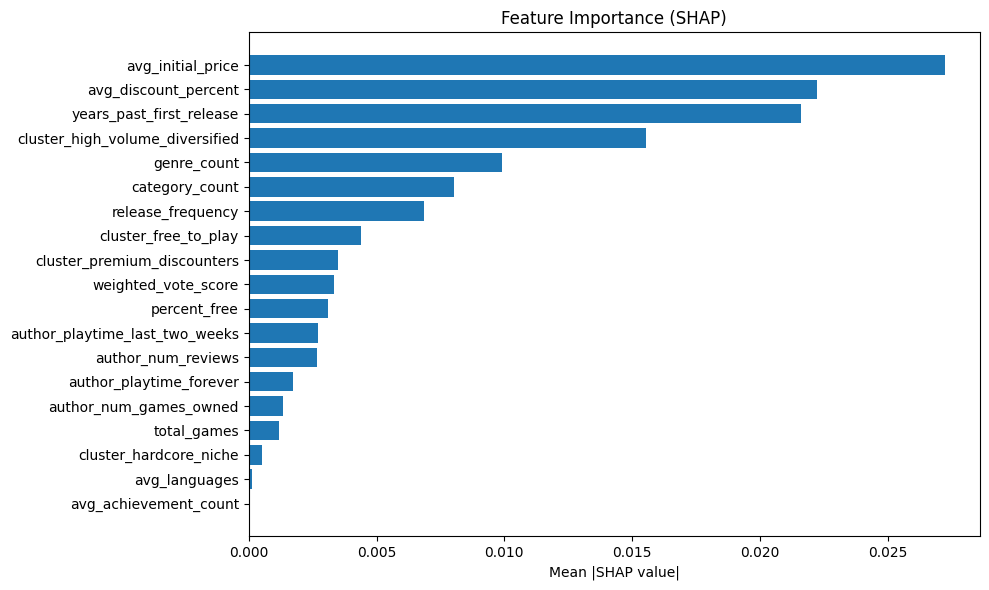

In [39]:
shap_bar_plot(lr_shap_values, feature_names=feature_names)

In [40]:
mean_abs_shap = np.mean(np.abs(lr_shap_values.values), axis=0)
threshold = np.max(mean_abs_shap) * 0.01
important_features = mean_abs_shap >= threshold
print(f"Number of important features: {np.sum(important_features)}")

Number of important features: 17


### Decision Tree

In [41]:
y_test = df_test['is_top'].copy()
X_test = df_test.drop(columns=['is_top']).copy()
X_test_scaled = scaler.transform(X_test)

feature_names = list(df_test.drop(columns=['is_top']).columns)

**Tree Plot**

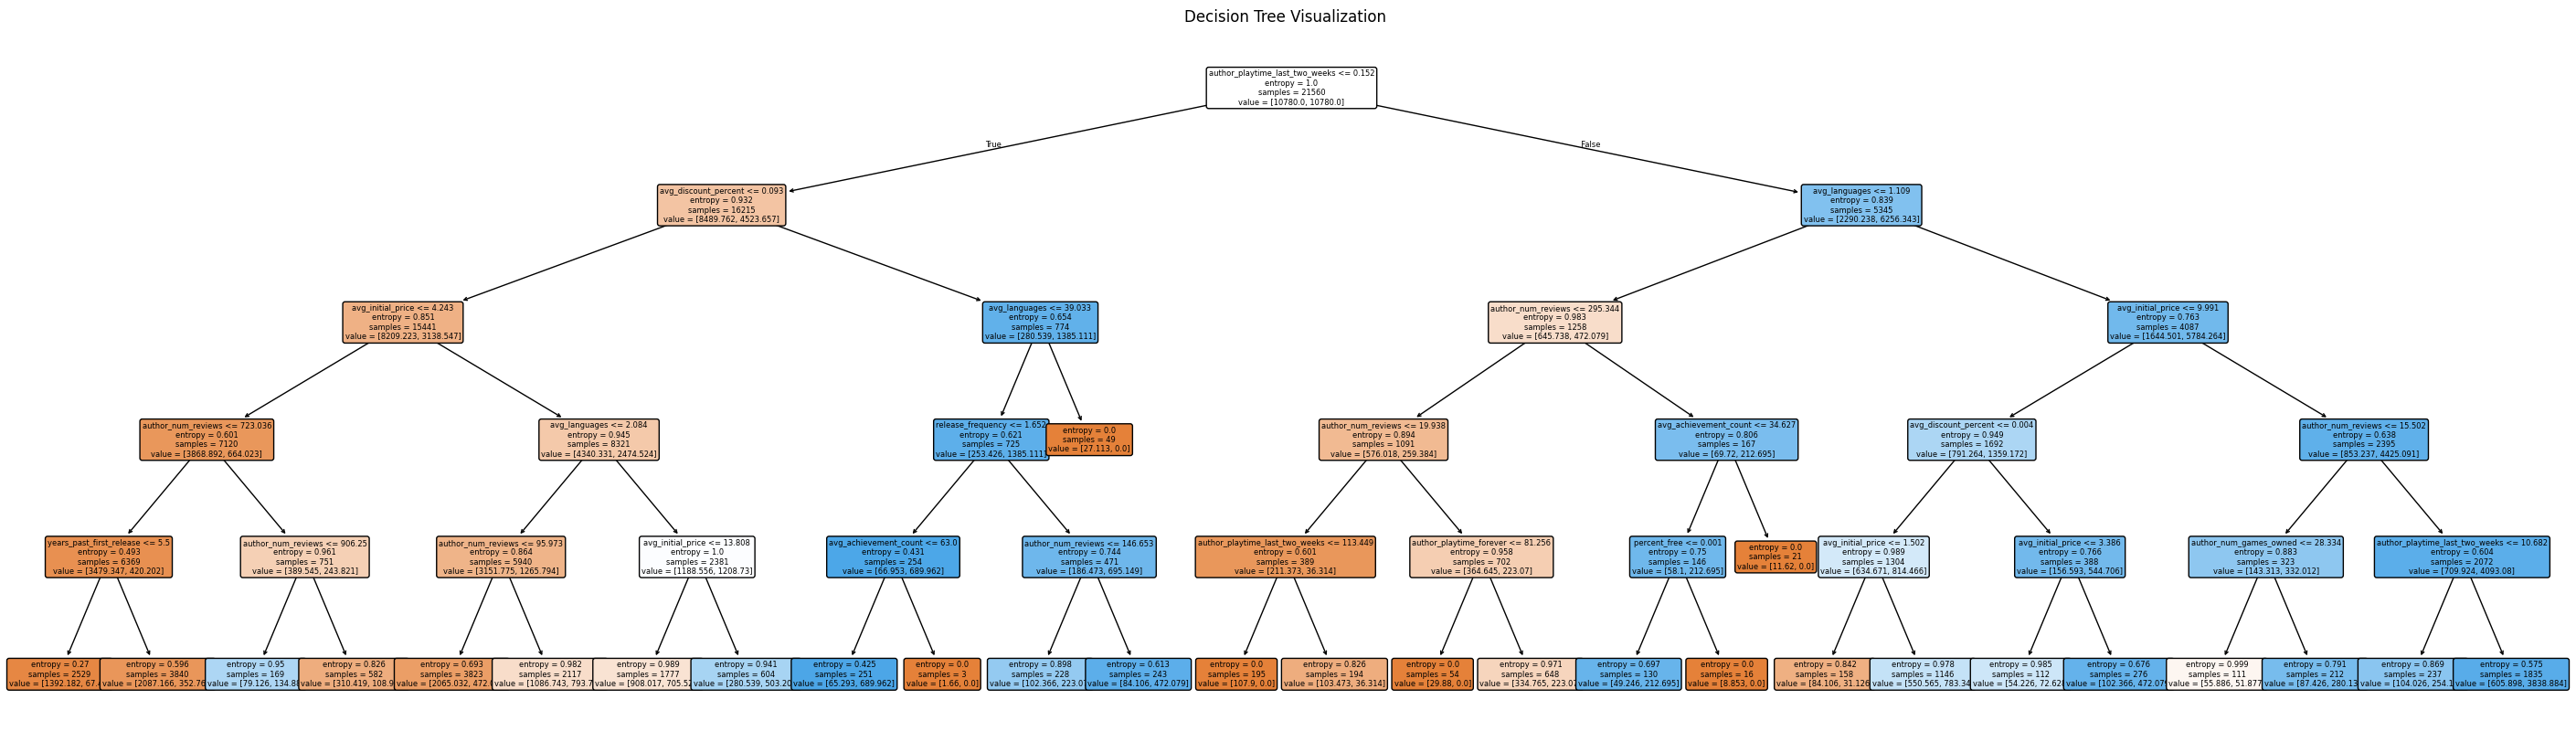

In [42]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(36, 10))
plot_tree(dt_best_model, feature_names=feature_names, filled=True, rounded=True, fontsize=6)
plt.title("Decision Tree Visualization")
plt.show()

**SHAP Values**

PermutationExplainer explainer: 5391it [02:24, 34.55it/s]                          


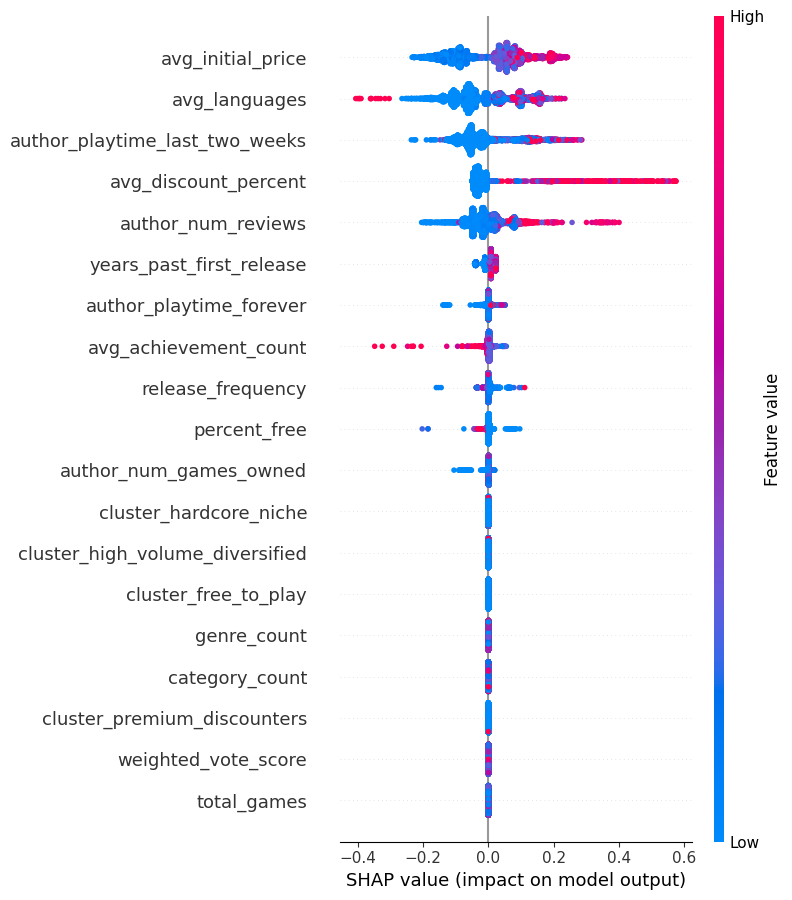

In [43]:
dt_shap_values = shap_importance(dt_best_model, X_test, feature_names)

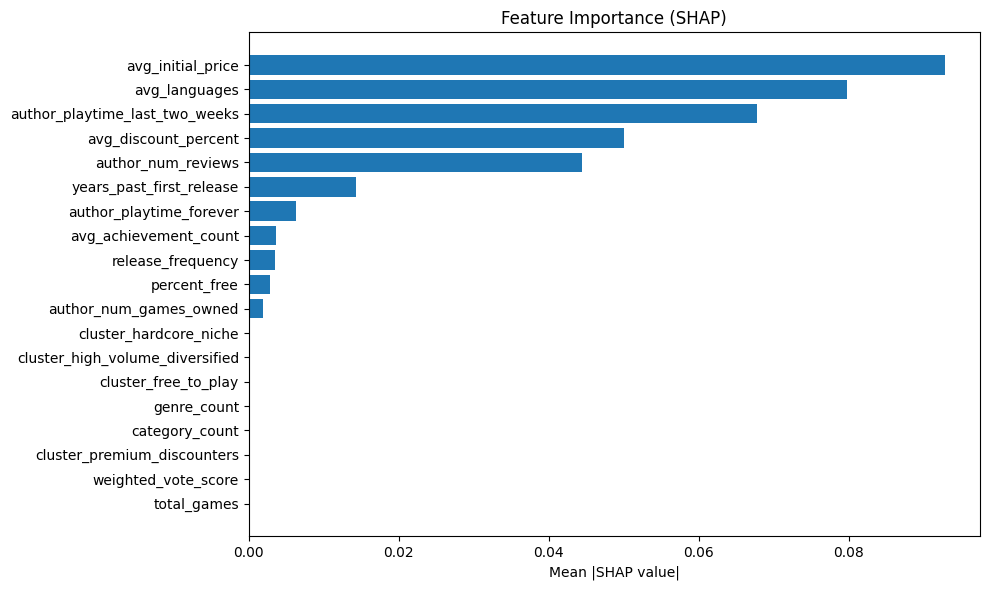

In [44]:
shap_bar_plot(dt_shap_values, feature_names=feature_names)

In [45]:
mean_abs_shap = np.mean(np.abs(dt_shap_values.values), axis=0)
threshold = np.max(mean_abs_shap) * 0.01
important_features = mean_abs_shap >= threshold
print(f"Number of important features: {np.sum(important_features)}")

Number of important features: 11


### Random Forest

In [46]:
y_test = df_test['is_top'].copy()
X_test = df_test.drop(columns=['is_top']).copy()
X_test_scaled = scaler.transform(X_test)

feature_names = list(df_test.drop(columns=['is_top']).columns)

**Importance Scores**

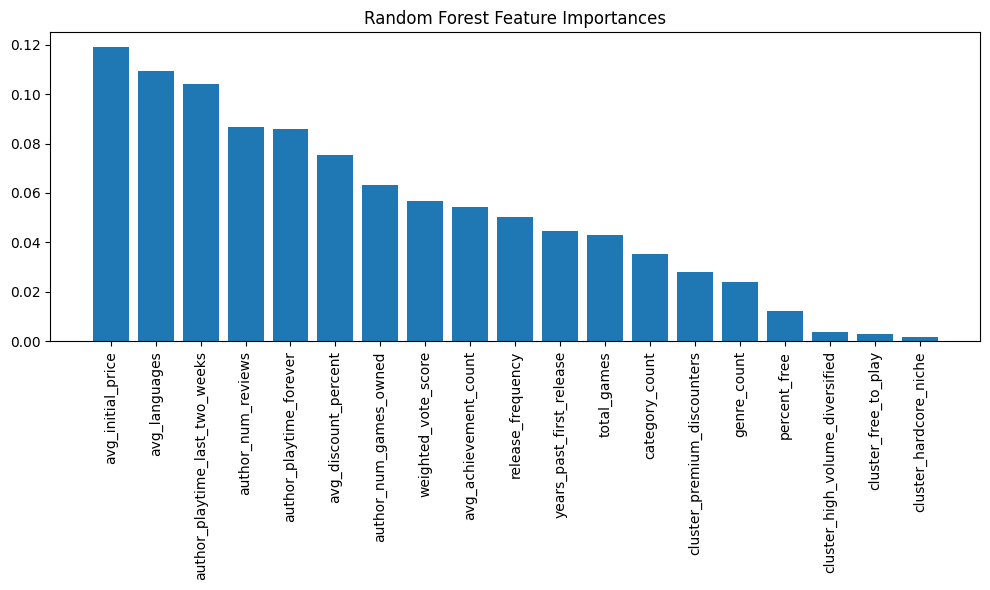

In [47]:
import matplotlib.pyplot as plt
import numpy as np


importances = rf_best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title('Random Forest Feature Importances')
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

**SHAP Values**

PermutationExplainer explainer: 5391it [3:01:10,  2.02s/it]


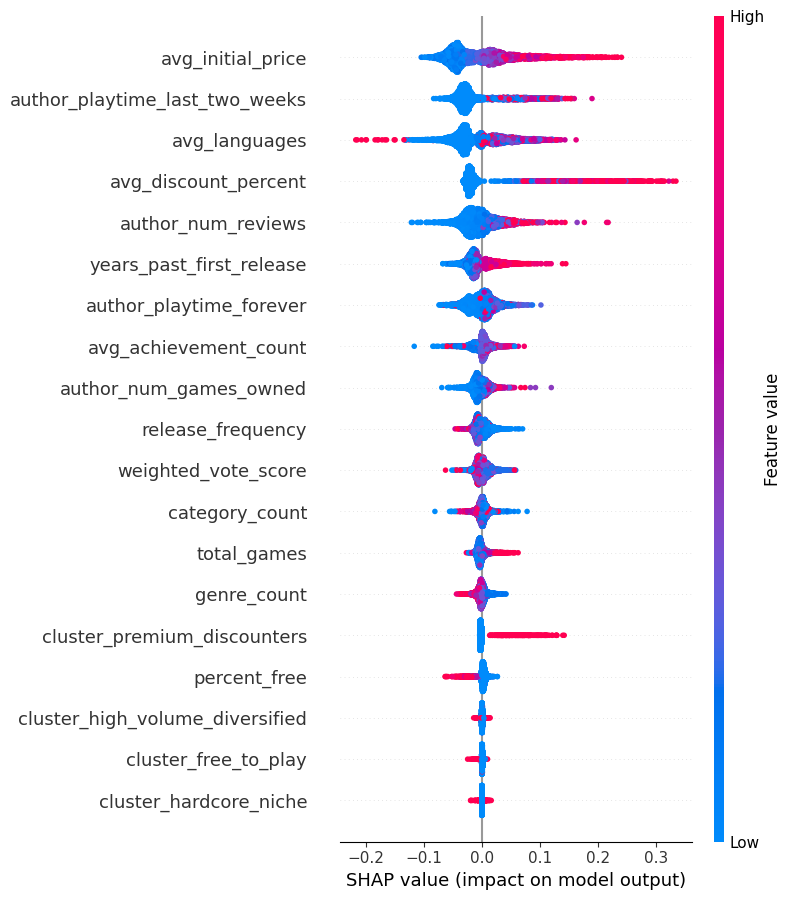

In [48]:
rf_shap_values = shap_importance(rf_best_model, X_test, feature_names)

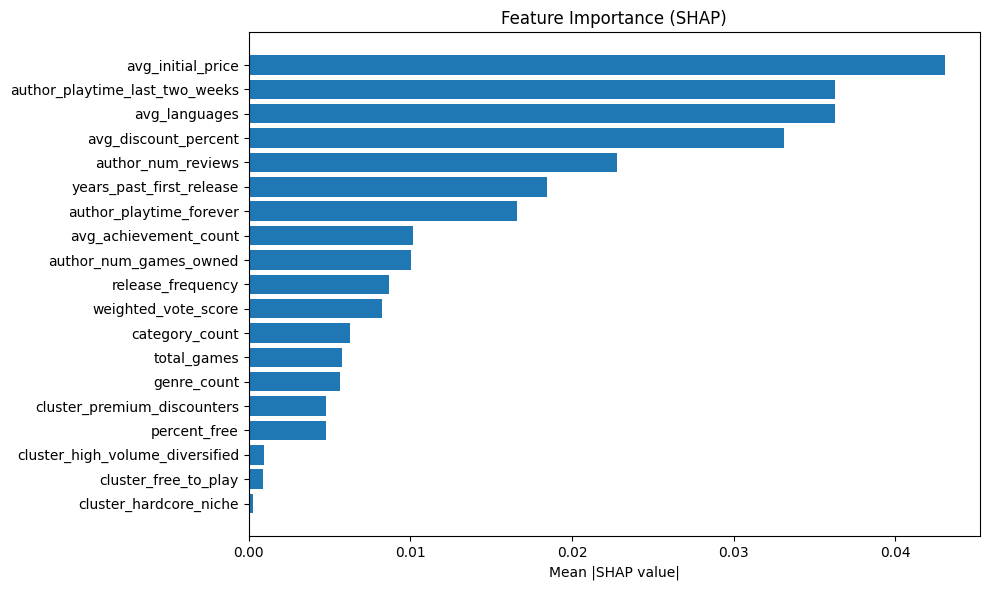

In [49]:
shap_bar_plot(rf_shap_values, feature_names=feature_names)

In [50]:
mean_abs_shap = np.mean(np.abs(rf_shap_values.values), axis=0)
threshold = np.max(mean_abs_shap) * 0.01
important_features = mean_abs_shap >= threshold
print(f"Number of important features: {np.sum(important_features)}")

Number of important features: 18


### Gradient Boosting

In [51]:
y_test = df_test['is_top'].copy()
X_test = df_test.drop(columns=['is_top']).copy()
X_test_scaled = scaler.transform(X_test)

feature_names = list(df_test.drop(columns=['is_top']).columns)

**Importance Scores**

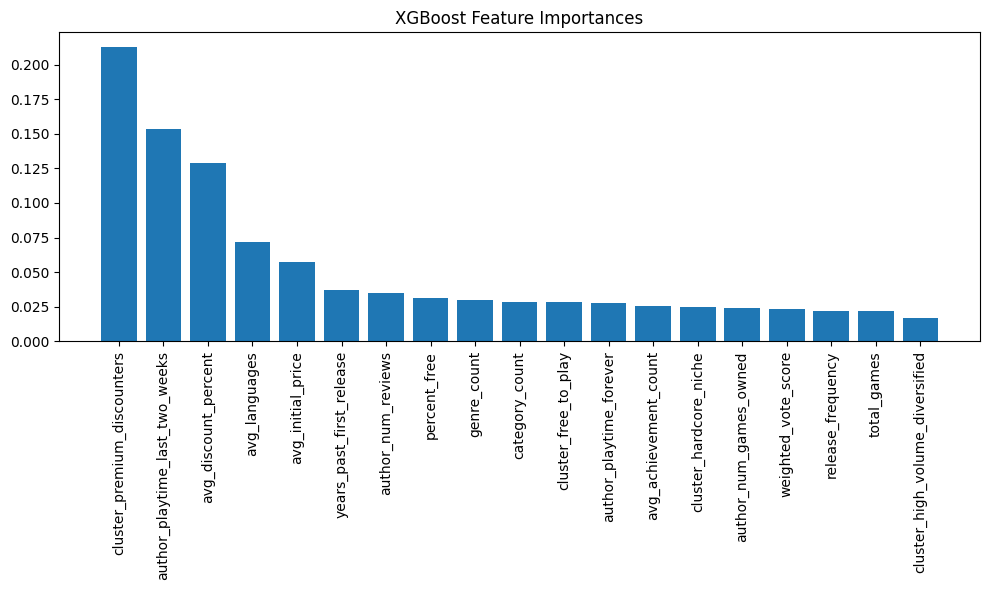

In [52]:
import matplotlib.pyplot as plt
import numpy as np


importances = gb_best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title('XGBoost Feature Importances')
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

**SHAP Values**

PermutationExplainer explainer: 5391it [16:49,  5.29it/s]


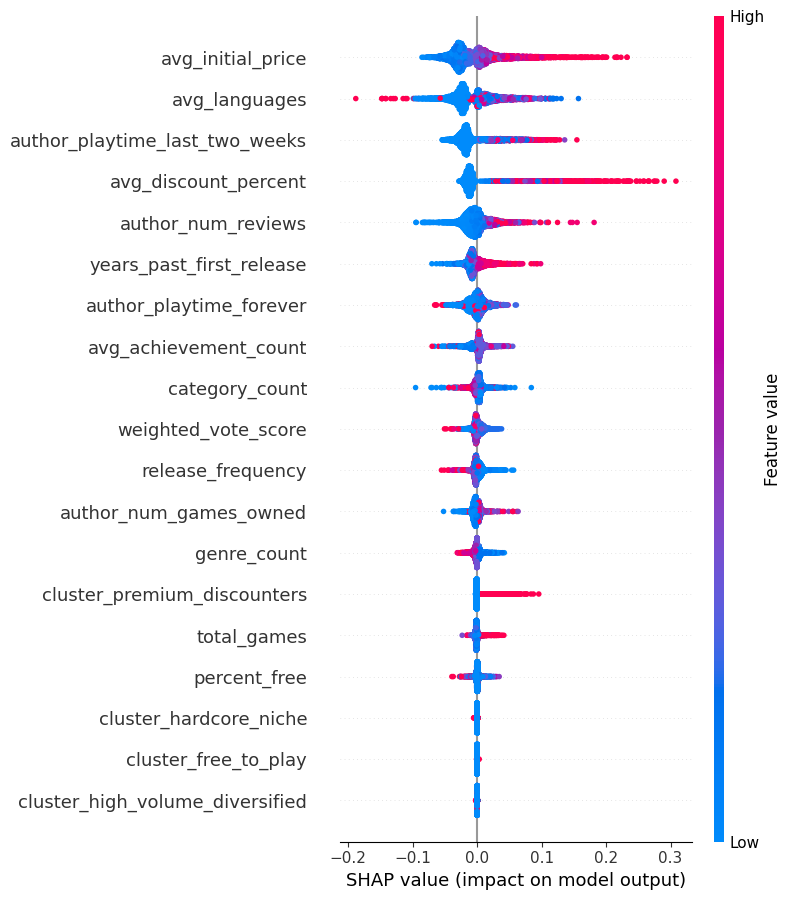

In [53]:
gb_shap_values = shap_importance(gb_best_model, X_test, feature_names)

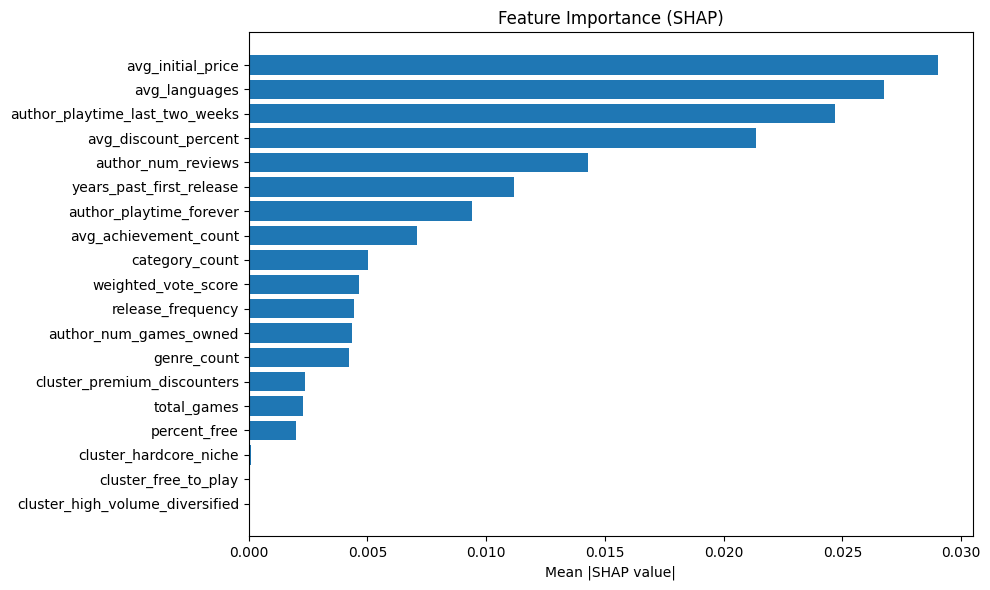

In [54]:
shap_bar_plot(gb_shap_values, feature_names=feature_names)

In [55]:
mean_abs_shap = np.mean(np.abs(gb_shap_values.values), axis=0)
threshold = np.max(mean_abs_shap) * 0.01
important_features = mean_abs_shap >= threshold
print(f"Number of important features: {np.sum(important_features)}")

Number of important features: 16


## ROC-AUC Score

Logistic Regression ROC‑AUC: 0.803
Decision Tree ROC‑AUC: 0.822
Random Forest ROC‑AUC: 0.882
XGBoost ROC‑AUC: 0.881
Decision Tree (calibrated) ROC‑AUC: 0.848
Random Forest (calibrated) ROC‑AUC: 0.882


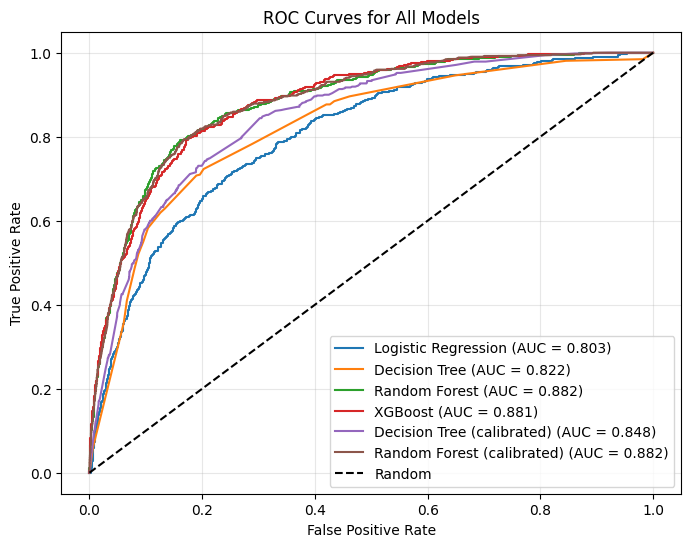

In [56]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Dictionary of models with descriptive names
models = {
    'Logistic Regression': lr_best_model,
    'Decision Tree': dt_best_model,
    'Random Forest': rf_best_model,
    'XGBoost': gb_best_model,
    'Decision Tree (calibrated)': dt_calibrated,
    'Random Forest (calibrated)': rf_calibrated,
}

plt.figure(figsize=(8, 6))

for name, model in models.items():

    X_test_model = data_dict[name]
    
    # Predict probabilities for the positive class
    y_pred_proba = model.predict_proba(X_test_model)[:, 1]
    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
    print(f'{name} ROC‑AUC: {auc:.3f}')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## Calibration Report

In [57]:
clf_list = [
    (lr_best_model, "Logistic Regression"),
    (dt_best_model, "Decision Tree"),
    (rf_best_model, "Random Forest"),
    (gb_best_model, "XGBoost"),
    (dt_calibrated, "Decision Tree (calibrated)"),
    (rf_calibrated, "Random Forest (calibrated)")
]

In [58]:
y_test = df_test['is_top'].copy()
X_test = df_test.drop(columns=['is_top']).copy()
X_test_scaled = scaler.transform(X_test)

data_dict = {
    'Logistic Regression': X_test_scaled,
    'Decision Tree': X_test,
    'Random Forest': X_test,
    'XGBoost': X_test,
    'Decision Tree (calibrated)': X_test,
    'Random Forest (calibrated)': X_test,
}

100%|██████████| 6/6 [00:01<00:00,  3.26it/s]


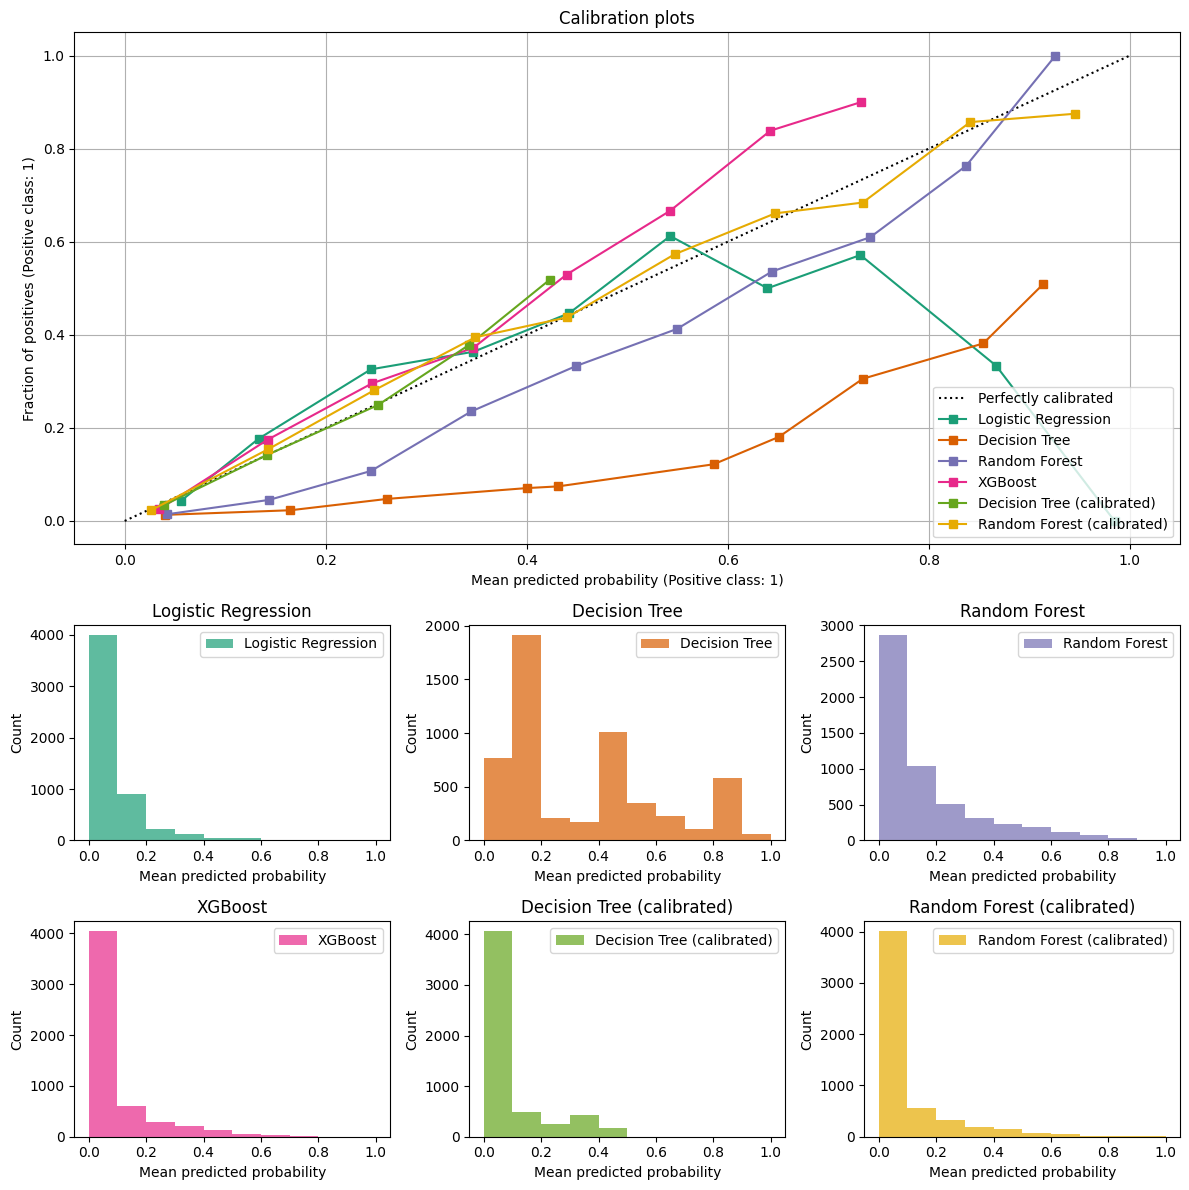


Calibration Metrics:
                     Model  Brier Score      ECE
       Logistic Regression     0.077686 0.024308
             Decision Tree     0.161381 0.253618
             Random Forest     0.070167 0.067751
                   XGBoost     0.064926 0.019444
Decision Tree (calibrated)     0.070767 0.009729
Random Forest (calibrated)     0.063955 0.008040


In [59]:
import pandas as pd
import numpy as np
from sklearn.metrics import brier_score_loss
from sklearn.calibration import CalibrationDisplay
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
from tqdm import tqdm


def expected_calibration_error(y_true, y_prob, n_bins=10):
    """Compute Expected Calibration Error (ECE)."""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        in_bin = (y_prob >= bin_boundaries[i]) & (y_prob < bin_boundaries[i+1])
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            avg_pred_prob = np.mean(y_prob[in_bin])
            true_fraction = np.mean(y_true[in_bin])
            ece += prop_in_bin * np.abs(avg_pred_prob - true_fraction)
    return ece

# Lists to store results
model_names = []
brier_scores = []
ece_scores = []

fig = plt.figure(figsize=(12, 12))
gs = GridSpec(4, 3, figure=fig)
colors = plt.get_cmap("Dark2")

ax_calibration_curve = fig.add_subplot(gs[:2, :3])
calibration_displays = {}

for i, (clf, name) in enumerate(tqdm(clf_list)):

    X_test_model = data_dict[name]
    
    # Get predicted probabilities on test set
    y_prob = clf.predict_proba(X_test_model)[:, 1]
    
    # Compute Brier score
    brier = brier_score_loss(y_test, y_prob)
    brier_scores.append(brier)
    
    # Compute ECE
    ece = expected_calibration_error(y_test, y_prob, n_bins=10)
    ece_scores.append(ece)
    
    model_names.append(name)
    
    # Calibration curve
    display = CalibrationDisplay.from_estimator(
        clf,
        X_test_model,
        y_test,
        n_bins=10,
        name=name,
        ax=ax_calibration_curve,
        color=colors(i),
    )
    calibration_displays[name] = display

ax_calibration_curve.grid()
ax_calibration_curve.set_title("Calibration plots")

# Histograms of predicted probabilities
grid_positions = [(2, 0), (2, 1), (2, 2), (3, 0), (3, 1), (3, 2)]
for i, (_, name) in enumerate(clf_list):
    row, col = grid_positions[i]
    ax = fig.add_subplot(gs[row, col])
    ax.hist(
        calibration_displays[name].y_prob,
        range=(0, 1),
        bins=10,
        label=name,
        color=colors(i),
        alpha=0.7
    )
    ax.set(title=name, xlabel="Mean predicted probability", ylabel="Count")
    ax.legend()

plt.tight_layout()
plt.show()

# Create DataFrame with calibration metrics
results_df = pd.DataFrame({
    'Model': model_names,
    'Brier Score': brier_scores,
    'ECE': ece_scores
})
print("\nCalibration Metrics:")
print(results_df.to_string(index=False))

## Precision and Recall on Test

In [60]:
y_test = df_test['is_top'].copy()
X_test = df_test.drop(columns=['is_top']).copy()
X_test_scaled = scaler.transform(X_test)

data_dict = {
    'Logistic Regression': X_test_scaled,
    'Decision Tree': X_test,
    'Random Forest': X_test,
    'XGBoost': X_test,
    'Decision Tree (calibrated)': X_test,
    'Random Forest (calibrated)': X_test,
}

In [61]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Dictionary of models and their corresponding thresholds
models_with_thresholds = {
    'Logistic Regression': (lr_best_model, lr_threshold),
    'Decision Tree': (dt_best_model, dt_threshold),
    'Random Forest': (rf_best_model, rf_threshold),
    'XGBoost': (gb_best_model, gb_threshold),
    'Decision Tree (calibrated)': (dt_calibrated, dt_calibrated_threshold),
    'Random Forest (calibrated)': (rf_calibrated, rf_calibrated_threshold),
}

print("Precision Report (test set, at optimal threshold):")
print("-" * 60)

for name, (model, threshold) in models_with_thresholds.items():

    X_test_model = data_dict[name]
    
    # Get predicted probabilities
    y_pred_proba = model.predict_proba(X_test_model)[:, 1]
    # Apply threshold
    y_pred = (y_pred_proba >= threshold).astype(int)
    # Compute metrics
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    print(f"{name}:")
    print(f"  Threshold = {threshold:.3f}")
    print(f"  Precision = {precision:.3f}")
    print(f"  Recall    = {recall:.3f}")
    print(f"  F1-score  = {f1:.3f}")
    print("-" * 60)

Precision Report (test set, at optimal threshold):
------------------------------------------------------------
Logistic Regression:
  Threshold = 0.253
  Precision = 0.408
  Recall    = 0.288
  F1-score  = 0.338
------------------------------------------------------------
Decision Tree:
  Threshold = 0.859
  Precision = 0.385
  Recall    = 0.358
  F1-score  = 0.371
------------------------------------------------------------
Random Forest:
  Threshold = 0.626
  Precision = 0.623
  Recall    = 0.248
  F1-score  = 0.355
------------------------------------------------------------
XGBoost:
  Threshold = 0.414
  Precision = 0.631
  Recall    = 0.246
  F1-score  = 0.354
------------------------------------------------------------
Decision Tree (calibrated):
  Threshold = 0.364
  Precision = 0.473
  Recall    = 0.271
  F1-score  = 0.345
------------------------------------------------------------
Random Forest (calibrated):
  Threshold = 0.444
  Precision = 0.602
  Recall    = 0.273
  F1-sc

## Recall Evaluation on Top Developers

In [62]:
# Dictionary of models and their corresponding thresholds
models_with_thresholds = {
    'Logistic Regression': (lr_best_model, lr_threshold),
    'Decision Tree': (dt_best_model, dt_threshold),
    'Random Forest': (rf_best_model, rf_threshold),
    'XGBoost': (gb_best_model, gb_threshold),
    'Decision Tree (calibrated)': (dt_calibrated, dt_calibrated_threshold),
    'Random Forest (calibrated)': (rf_calibrated, rf_calibrated_threshold),
}

In [63]:
df_top = df_emerging[df_emerging['is_top'] == 1]

In [64]:
y_top = df_top['is_top'].copy()
X_top = df_top.drop(columns=['is_top']).copy()
X_top_scaled = scaler.transform(X_top)

data_dict = {
    'Logistic Regression': X_top_scaled,
    'Decision Tree': X_top,
    'Random Forest': X_top,
    'XGBoost': X_top,
    'Decision Tree (calibrated)': X_top,
    'Random Forest (calibrated)': X_top,
}

In [65]:
from sklearn.metrics import recall_score


print("Recall Report (top emerging devs set, at optimal threshold):")
print("-" * 60)

for name, (model, threshold) in models_with_thresholds.items():

    X_test_model = data_dict[name]
    y_pred_proba = model.predict_proba(X_test_model)[:, 1]
    y_pred = (y_pred_proba > threshold).astype(np.int32)

    recall = recall_score(y_top, y_pred)

    print(f"{name}:")
    print(f"  Threshold = {threshold:.3f}")
    print(f"  Recall    = {recall:.3f}")
    print("-" * 60)

Recall Report (top emerging devs set, at optimal threshold):
------------------------------------------------------------
Logistic Regression:
  Threshold = 0.253
  Recall    = 0.078
------------------------------------------------------------
Decision Tree:
  Threshold = 0.859
  Recall    = 0.334
------------------------------------------------------------
Random Forest:
  Threshold = 0.626
  Recall    = 0.128
------------------------------------------------------------
XGBoost:
  Threshold = 0.414
  Recall    = 0.152
------------------------------------------------------------
Decision Tree (calibrated):
  Threshold = 0.364
  Recall    = 0.213
------------------------------------------------------------
Random Forest (calibrated):
  Threshold = 0.444
  Recall    = 0.144
------------------------------------------------------------


## Emerging Developers Search Performance

In [66]:
import pandas as pd
import numpy as np

def evaluate_emerging_ranking(y_pred_proba, X_test, probability_threshold=0.7):
    """
    Evaluate whether at least 5 emerging non‑top developers have predicted probability
    above the given threshold (default 0.7). Returns a report of those developers.

    Parameters
    ----------
    y_pred_proba : array-like
        Predicted probabilities for the test set (positive class).
    X_test : pd.DataFrame
        Test set DataFrame. Must contain columns:
        - 'years_past_first_release'
        - 'is_top'
    probability_threshold : float, default=0.7
        The absolute probability threshold considered as "enough evidence".

    Returns
    -------
    report : pd.DataFrame
        Table of emerging non‑top developers with probability > threshold, sorted descending.
    success : bool
        True if at least 5 such developers exist.
    """
    # Identify emerging non‑top developers
    emerging_mask = (X_test['years_past_first_release'] <= 3) & (X_test['is_top'] == 0)
    if not emerging_mask.any():
        print("No emerging non‑top developers in the test set.")
        return None, False

    # Get their predicted probabilities
    emerging_proba = y_pred_proba[emerging_mask]
    emerging_indices = emerging_mask[emerging_mask].index

    # Keep only those with probability > threshold
    high_conf_mask = emerging_proba > probability_threshold
    high_conf_indices = emerging_indices[high_conf_mask]
    high_conf_proba = emerging_proba[high_conf_mask]

    # Sort descending by probability
    sort_idx = np.argsort(high_conf_proba)[::-1]
    sorted_indices = high_conf_indices[sort_idx]
    sorted_proba = high_conf_proba[sort_idx]

    # Build report
    report_data = []
    for i, (idx, proba) in enumerate(zip(sorted_indices, sorted_proba), 1):
        report_data.append({
            'Rank': i,
            'Developer ID': idx,
            'Predicted Probability': f"{proba:.3f}"
        })

    report_df = pd.DataFrame(report_data)
    success = len(report_df) >= 5

    print(f"Found {len(report_df)} emerging non‑top developers with probability > {probability_threshold}")
    if success:
        print("Business success criterion met: at least 5 developers have sufficient evidence.")
    else:
        print("Business success criterion NOT met.")

    return report_df, success

In [67]:
models = {
    'Logistic Regression': lr_best_model,
    'Decision Tree': dt_best_model,
    'Random Forest': rf_best_model,
    'XGBoost': gb_best_model,
    'Decision Tree (calibrated)': dt_calibrated,
    'Random Forest (calibrated)': rf_calibrated,
}

In [68]:
df_rank = df_emerging[df_emerging['is_top'] == 0]

In [69]:
y_rank = df_rank['is_top'].copy()
X_rank = df_rank.drop(columns=['is_top']).copy()
X_rank_scaled = scaler.transform(X_rank)

data_dict = {
    'Logistic Regression': X_rank_scaled,
    'Decision Tree': X_rank,
    'Random Forest': X_rank,
    'XGBoost': X_rank,
    'Decision Tree (calibrated)': X_rank,
    'Random Forest (calibrated)': X_rank,
}

In [70]:
for name, model in models.items():

    X_test_model = data_dict[name]
    y_test_pred_proba = model.predict_proba(X_test_model)[:, 1]

    print(f"{name}:")
    report, success = evaluate_emerging_ranking(y_test_pred_proba, df_rank, probability_threshold=0.7)
    print("Passed the business success criterion" if success else "Failed to pass the business success criterion")
    print()

Logistic Regression:
Found 26 emerging non‑top developers with probability > 0.7
Business success criterion met: at least 5 developers have sufficient evidence.
Passed the business success criterion

Decision Tree:
Found 2238 emerging non‑top developers with probability > 0.7
Business success criterion met: at least 5 developers have sufficient evidence.
Passed the business success criterion

Random Forest:
Found 48 emerging non‑top developers with probability > 0.7
Business success criterion met: at least 5 developers have sufficient evidence.
Passed the business success criterion

XGBoost:
Found 0 emerging non‑top developers with probability > 0.7
Business success criterion NOT met.
Failed to pass the business success criterion

Decision Tree (calibrated):
Found 0 emerging non‑top developers with probability > 0.7
Business success criterion NOT met.
Failed to pass the business success criterion

Random Forest (calibrated):
Found 3 emerging non‑top developers with probability > 0.7
Bu